# Análise Preditiva - Modelo CART e Random Forest
By Iasmin Marques
---


Dados Link da fonte de dados: https://opendatasus.saude.gov.br/dataset/srag-2021-a-2024

Link do repositorio do github https://github.com/iasminimp/srag_tcc





---
Nesse collab possui o modelo que associa os fatores de risco a variavel desfecho/ evolução. Com os algoritmos Random Forest e o modelo CART com a exibição da importancia das variaveis (feature importance).

---
Informações sobre as variaveis do dataset

* `FATOR_RISC`: Paciente apresenta algum fator de risco;
Onde:
1-Sim
2-Não
9-Ignorado

`Campo de fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]`

`MORB_DESC`: Listar outro(s) fator(es) de risco do paciente;
e `outros campos de fatores risco`: são padronizados como:

1-Sim

2-Não

9-Ignorado

* `EVOLUCAO`: evolução do caso
Onde,

1-Cura

2-Óbito

3- Óbito por outras causas

9-Ignorado
<br/>


Obs.: o dataset esta desbalanceado, onde no campo de `EVOLUCAO`, temos:

212.812 - 1 CURA

20.207 - 2 Óbito

7.615 - 3 Óbito por outras causas

5.538 - 9-Ignorado


# Modelo CART (Decision Tree)

In [ ]:
# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)
df

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
2,15/01/2024,3,10/01/2024,2,PB,I NRS JOAO PESSOA,1377.0,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,16/01/2024,3,14/01/2024,3,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266427,16/12/2024,51,13/12/2024,50,SP,GVE XXXI SOROCABA,1353.0,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [ ]:
# 📌 3. Pré-processamento (versão corrigida e segura)
# Filtrar apenas os registros com evolução "Cura (1)" e "Óbito (2)"
df = df[df['EVOLUCAO'].isin([1, 2])].copy()  # <- importante: .copy() evita o warning

# Mapear valores: 1 → 0 (Cura), 2 → 1 (Óbito)
df.loc[:, 'EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})

# Lista de colunas com fatores de risco
fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

# Garantir que os fatores de risco sejam numéricos
df.loc[:, fatores_risco] = df[fatores_risco].apply(pd.to_numeric, errors='coerce')

# Remover linhas com valores ausentes nessas colunas
df.dropna(subset=fatores_risco + ['EVOLUCAO'], inplace=True)

# Separar variáveis preditoras (X) e variável alvo (y)
X = df[fatores_risco]
y = df['EVOLUCAO']

In [ ]:
# 📌 4. Balanceamento
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [ ]:
# 📌 5. Treinamento com CART
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_res, y_res)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
# 📌 6. Avaliação
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)
y_pred = clf.predict(X_test)

print("📊 Classification Report:\n", classification_report(y_test, y_pred))
print("📉 Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.64      0.54      0.59     15201
         1.0       0.60      0.69      0.64     14981

    accuracy                           0.61     30182
   macro avg       0.62      0.62      0.61     30182
weighted avg       0.62      0.61      0.61     30182

📉 Matriz de Confusão:
 [[ 8265  6936]
 [ 4692 10289]]


<ipython-input-7-46f119969476>:14: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-7-46f119969476>:14: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-7-46f119969476>:14: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

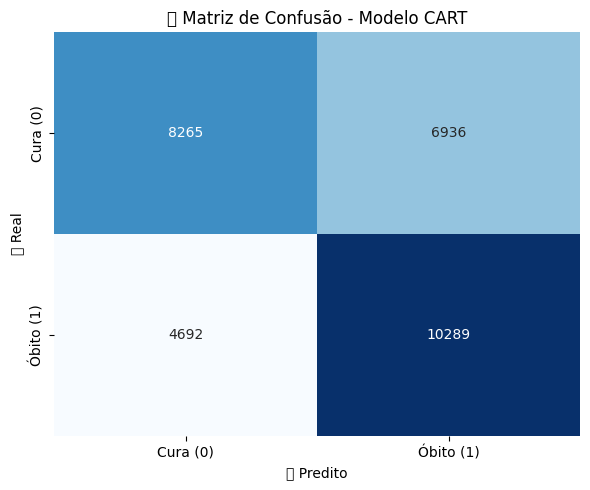

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de confusão aprimorada
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('🔮 Predito')
plt.ylabel('🎯 Real')
plt.title('📉 Matriz de Confusão - Modelo CART')
plt.tight_layout()
plt.show()


<ipython-input-8-f5be67c2f2e3>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Feature', data=importancias, palette='viridis')


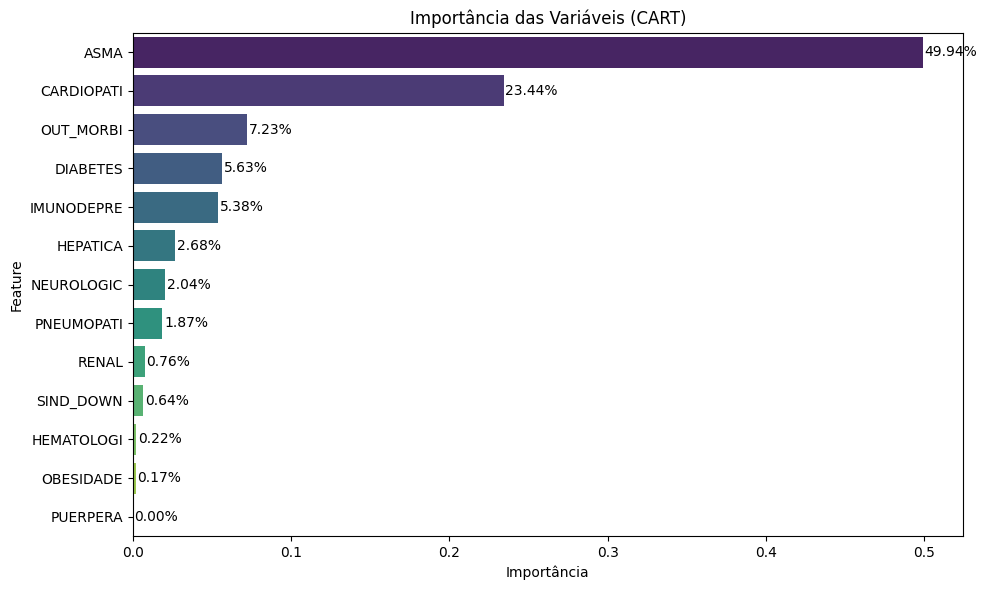

In [ ]:
# 📌 7. Importância das features
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': clf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importância', y='Feature', data=importancias, palette='viridis')
plt.title('Importância das Variáveis (CART)')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()

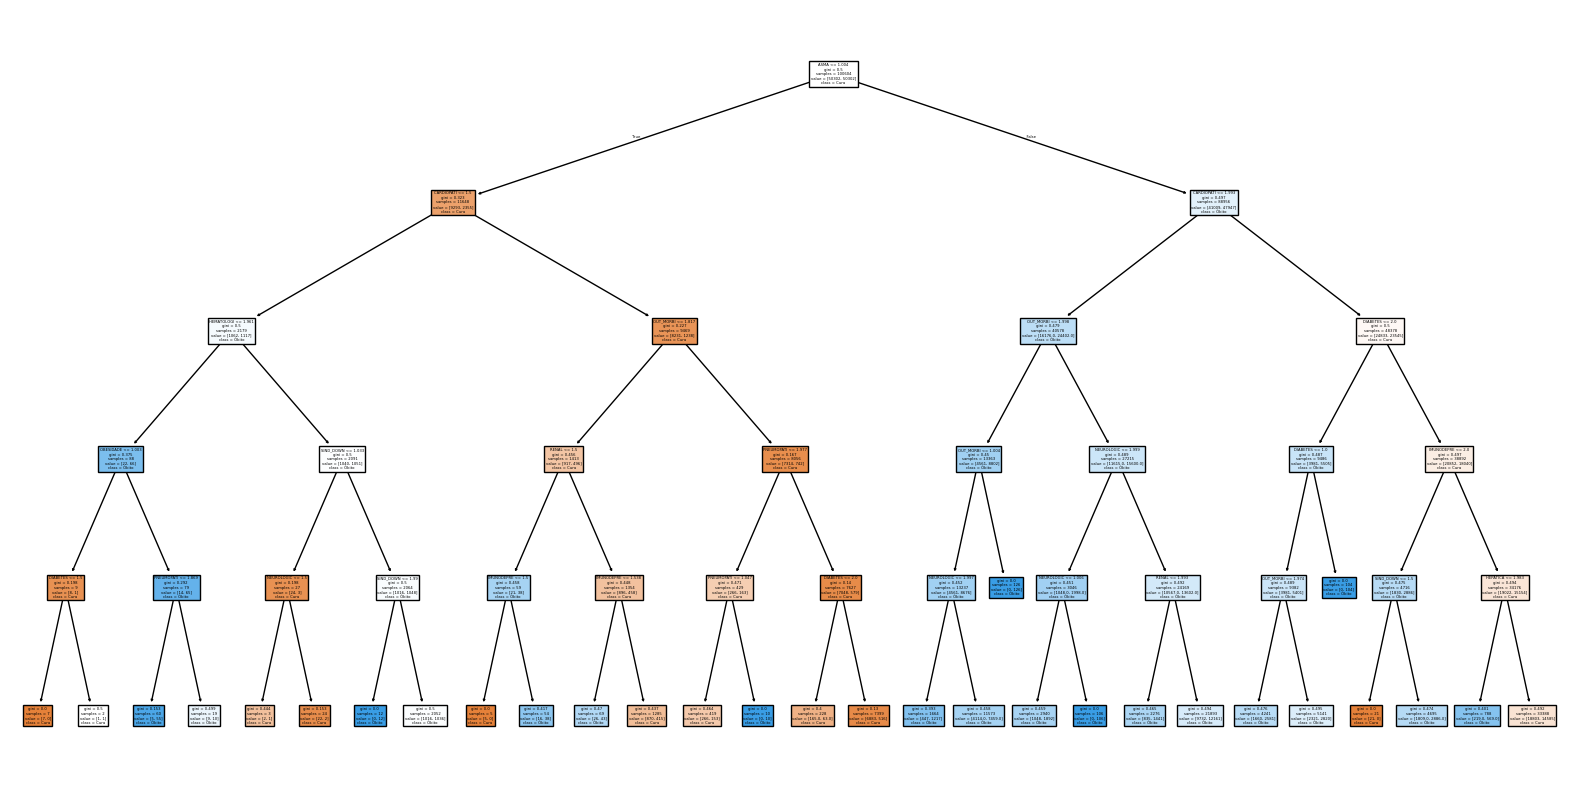

In [ ]:
# 📌 8. Visualização da árvore
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['Cura', 'Óbito'], filled=True)
plt.show()

# Modelo Random Forest

In [ ]:
# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)
df

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
2,15/01/2024,3,10/01/2024,2,PB,I NRS JOAO PESSOA,1377.0,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,16/01/2024,3,14/01/2024,3,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266427,16/12/2024,51,13/12/2024,50,SP,GVE XXXI SOROCABA,1353.0,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [ ]:
# 📌 3. Pré-processamento (versão segura)
# Filtrar apenas os casos de evolução 1 (cura) e 2 (óbito)
df = df[df['EVOLUCAO'].isin([1, 2])].copy()  # <- Faz uma cópia segura

# Mapear os valores: 1 → 0 (cura), 2 → 1 (óbito)
df.loc[:, 'EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})

# Lista de variáveis de fatores de risco
fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

# Converter fatores de risco para numérico com segurança
df.loc[:, fatores_risco] = df[fatores_risco].apply(pd.to_numeric, errors='coerce')

# Remover registros com valores ausentes nas variáveis selecionadas
df.dropna(subset=fatores_risco + ['EVOLUCAO'], inplace=True)

# Definir variáveis preditoras (X) e alvo (y)
X = df[fatores_risco]
y = df['EVOLUCAO']


In [ ]:
# 📌 4. Balanceamento com SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [ ]:
# 📌 5. Treinamento com Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_res, y_res)

RandomForestClassifier(random_state=42)

In [ ]:
# 📌 6. Avaliação
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)
y_pred = rf.predict(X_test)

print("📊 Classification Report:\n", classification_report(y_test, y_pred))
print("📉 Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.68      0.54      0.60     15201
         1.0       0.61      0.74      0.67     14981

    accuracy                           0.64     30182
   macro avg       0.65      0.64      0.64     30182
weighted avg       0.65      0.64      0.64     30182

📉 Matriz de Confusão:
 [[ 8201  7000]
 [ 3844 11137]]


<ipython-input-25-b477c0fad98a>:14: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-25-b477c0fad98a>:14: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-25-b477c0fad98a>:14: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes

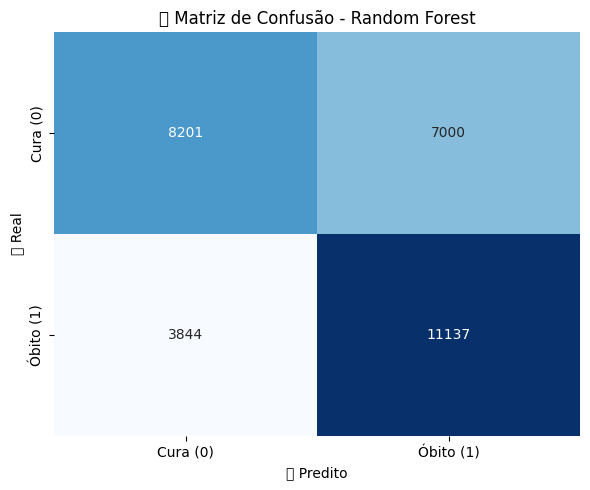

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de confusão aprimorada
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('🔮 Predito')
plt.ylabel('🎯 Real')
plt.title('📉 Matriz de Confusão - Random Forest')
plt.tight_layout()
plt.show()

<ipython-input-11-ba50dffb1a3c>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Feature', data=importancias, palette='mako')


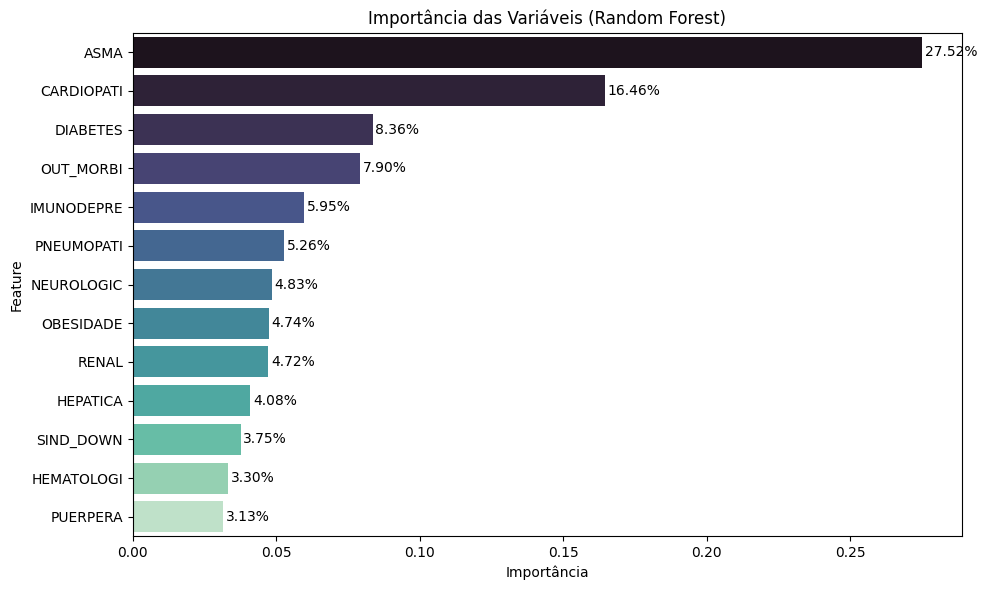

In [ ]:
# 📌 7. Importância das features
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': rf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importância', y='Feature', data=importancias, palette='mako')
plt.title('Importância das Variáveis (Random Forest)')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()

# Resultado CART vs RandomForest

| Modelo           | Acurácia | Precision (Óbito) | Recall (Óbito) | F1-score (Óbito) |
| ---------------- | -------- | ----------------- | -------------- | ---------------- |
| **CART**         | 0.61     | 0.60              | 0.69           | 0.64             |
| **RandomForest** | 0.64     | 0.61              | 0.74           | 0.67             |

 1. Acurácia
CART: 61%

Random Forest: 64%

Random Forest tem uma melhor taxa de acerto geral na predição dos desfechos.

 2. Recall (Óbito)

`Entre todos os óbitos reais, quantos foram corretamente identificados?`

CART: 0.69 → 69% dos óbitos foram corretamente detectados.

Random Forest: 0.74 → 74% dos óbitos foram detectados.
✅ Melhor em sensibilidade, o que é crucial em saúde pública (melhor detectar quem está em risco!).

3. Precision (Óbito)

` Entre os casos preditos como óbitos, quantos realmente eram óbitos? `

CART: 0.60

Random Forest: 0.61
✅ Muito próximo, com leve vantagem para o Random Forest.


4. F1-Score (Óbito)

`Harmonia entre precisão e recall: melhor métrica para dados desbalanceados.`

CART: 0.64

Random Forest: 0.67
✅ O Random Forest equilibra melhor sensibilidade e precisão, mesmo em um cenário desbalanceado

### *Matriz de Confusão*
* Random Forest reduz falsos negativos (menos pessoas com risco real sendo classificadas como cura)

### Conclusão
O Random Forest supera o CART em todos os principais indicadores.

É especialmente melhor em recall para óbitos, o que é essencial em modelos preditivos na área da saúde.

Portanto, Random Forest é o modelo mais indicado neste cenário para prever desfecho clínico com base nos fatores de risco.



# Random Forest com OOB Score

 OOB score (out-of-bag score) é uma técnica específica e muito útil ao utilizar Random Forests. Ele serve como uma estimativa interna de performance do modelo, permitindo avaliar e calibrar sem a necessidade de uma validação cruzada (cross-validation). Vamos por partes:

 ### O que é o OOB Score?

 Durante o treinamento de um modelo Random Forest, cada árvore é treinada com um bootstrap sample, ou seja, uma amostra aleatória com reposição do dataset.

Isso significa que, em média, cerca de 1/3 dos dados não são usados para treinar uma determinada árvore. Esses dados são chamados de out-of-bag (OOB) para essa árvore.

O OOB score avalia a performance do modelo usando essas amostras OOB, como se fossem dados de validação.



In [ ]:
# ✅ 1. Importação
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)
df

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
2,15/01/2024,3,10/01/2024,2,PB,I NRS JOAO PESSOA,1377.0,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,16/01/2024,3,14/01/2024,3,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266427,16/12/2024,51,13/12/2024,50,SP,GVE XXXI SOROCABA,1353.0,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [ ]:
# ✅ 3. Pré-processamento
df = df[df['EVOLUCAO'].isin([1, 2])]  # Mantendo apenas Cura (1) e Óbito (2)
df.loc[:, 'EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})  # 0 = Cura, 1 = Óbito

fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

df[fatores_risco] = df[fatores_risco].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=fatores_risco + ['EVOLUCAO'])

<ipython-input-80-dc9e9d458358>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[fatores_risco] = df[fatores_risco].apply(pd.to_numeric, errors='coerce')


In [ ]:
# ✅ 4. Separação das features e target
X = df[fatores_risco]
y = df['EVOLUCAO']

In [ ]:
# ✅ 5. Modelo com Random Forest + OOB
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    class_weight='balanced',  # ajuda com o desbalanceamento
    n_jobs=-1
)

modelo.fit(X, y)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, oob_score=True,
                       random_state=42)

In [ ]:
# ✅ 6. Avaliação
print("🌱 OOB Score (generalização estimada):", modelo.oob_score_)

# Previsão no mesmo conjunto (já que não usamos split nem validação cruzada aqui)
y_pred = modelo.predict(X)

print("\n📊 Classification Report:")
print(classification_report(y, y_pred))

🌱 OOB Score (generalização estimada): 0.5496949945683964

📊 Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.53      0.67     50302
         1.0       0.23      0.74      0.35      9533

    accuracy                           0.56     59835
   macro avg       0.57      0.63      0.51     59835
weighted avg       0.81      0.56      0.62     59835



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


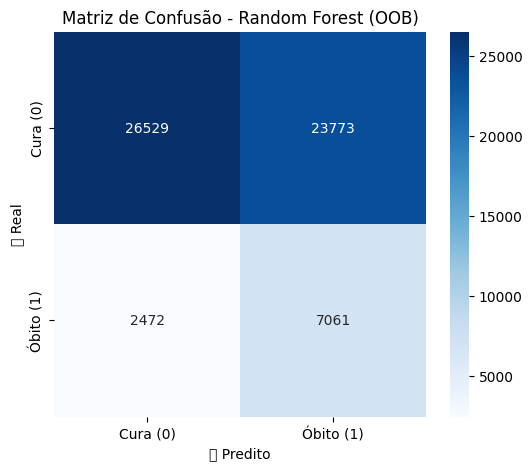

In [ ]:
# ✅ 7. Matriz de Confusão Visual
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Cura (0)', 'Óbito (1)'], yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel("🔮 Predito")
plt.ylabel("✅ Real")
plt.title("Matriz de Confusão - Random Forest (OOB)")
plt.show()

<ipython-input-85-3b644518c703>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Feature', data=importancias, palette='coolwarm')
<ipython-input-85-3b644518c703>:13: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


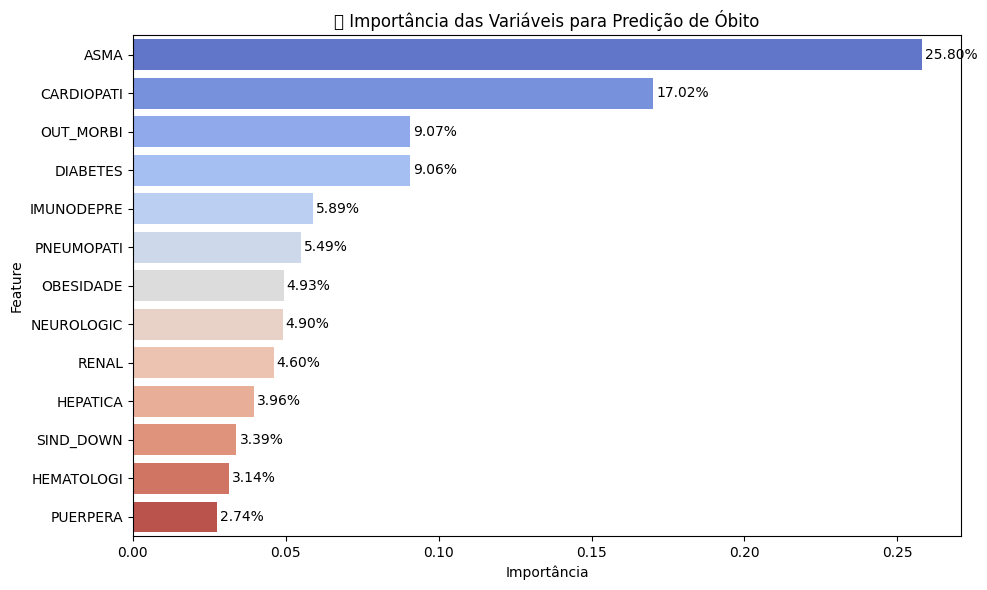

In [ ]:
# ✅ 8. Importância das Features
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': modelo.feature_importances_
}).sort_values(by='Importância', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importância', y='Feature', data=importancias, palette='coolwarm')
plt.title('📌 Importância das Variáveis para Predição de Óbito')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()

### Resumo do Modelo Random Forest com OOB


| Métrica                 | Classe 0 (Cura) | Classe 1 (Óbito) | Geral         |
| ----------------------- | --------------- | ---------------- | ------------- |
| **Precisão**            | 0.91            | 0.23             | —             |
| **Revocação (Recall)**  | 0.53            | 0.74             | —             |
| **F1-Score**            | 0.67            | 0.35             | —             |
| **Acurácia**            | —               | —                | **0.56**      |
| **OOB Score**           | —               | —                | **0.55**      |
| **Amostras por classe** | 50.302 (Cura)   | 9.533 (Óbito)    | Total: 59.835 |


* Desempenho no Recall (Sensibilidade):

Para classe 1 (Óbito): 74% dos óbitos foram corretamente detectados (recall = 0.74).

Isso é positivo, pois indica que o modelo consegue detectar a maioria dos casos fatais.

Porém, a baixa precisão (0.23) mostra que muitos pacientes curados estão sendo classificados como óbito (alto falso positivo).

* Classe Desbalanceada:

O desbalanceamento é evidente: para cada 5 pacientes curados, há 1 óbito.

O modelo priorizou a revocação para óbito, mas isso causou queda na precisão geral.

Mesmo com class_weight='balanced', o modelo ainda está descompensando para tentar acertar os óbitos.

* OOB Score vs Acurácia Real:

oob_score = 0.55 está próximo da acurácia real = 0.56, o que é bom: o OOB está estimando de forma coerente a generalização do modelo.

* F1-Score da classe 1 (Óbito):

F1 = 0.35 — mostra que o modelo está melhor que o acaso, mas ainda limitado na capacidade de classificar óbitos com precisão e equilíbrio.




| Aspecto                          | Avaliação                                                       |
| -------------------------------- | --------------------------------------------------------------- |
| ⚠️ Alta Revocação (Recall) Óbito | 👍 Bom (0.74)                                                   |
| ❌ Baixa Precisão Óbito           | 👎 Ruim (0.23) — muitos falsos positivos                        |
| 🧪 OOB Score ≈ Acurácia          | 👍 OOB confiável como métrica                                   |
| ⚖️ Desbalanceamento impactante   | ⚠️ Ainda precisa ser melhor tratado (ex: `SMOTE` ou `ensemble`) |
| 🔍 Importâncias das Features     | Ainda útil para análise clínica interpretável                   |


<ipython-input-89-337b3d1e4c5f>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})
<ipython-input-89-337b3d1e4c5f>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[fatores_risco] = df[fatores_risco].apply(pd.to_numeric, errors='coerce')


🌱 Melhores hiperparâmetros: {'rf__class_weight': 'balanced', 'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 2, 'rf__n_estimators': 100}

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.54      0.67     15091
           1       0.22      0.69      0.33      2860

    accuracy                           0.56     17951
   macro avg       0.56      0.61      0.50     17951
weighted avg       0.79      0.56      0.62     17951

📉 Matriz de Confusão:
 [[8105 6986]
 [ 892 1968]]


<ipython-input-89-337b3d1e4c5f>:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Feature', data=importancias, palette='mako')


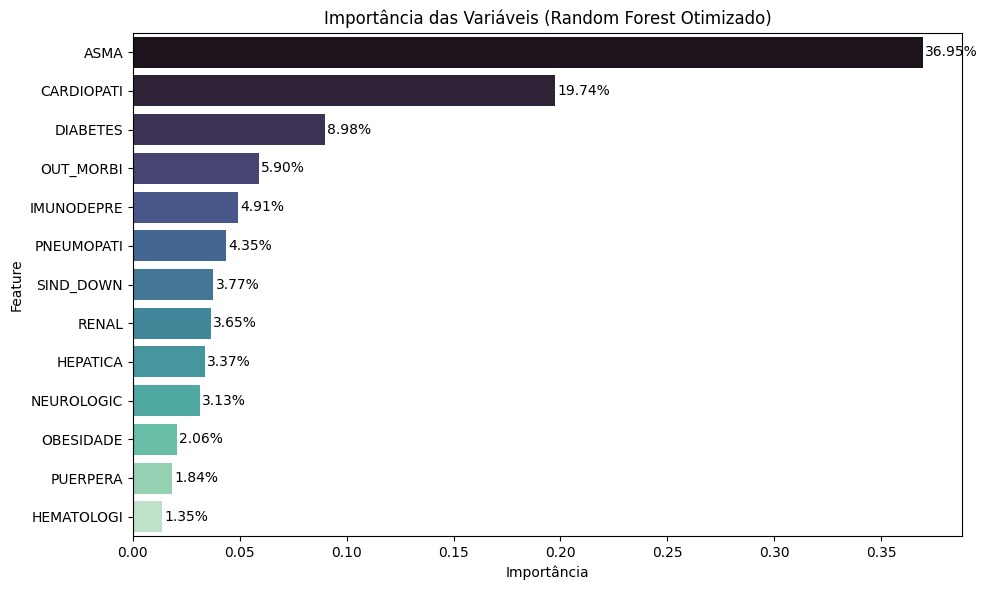

In [ ]:
# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 2. Carregando o dataset
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

# 📌 3. Pré-processamento
df = df[df['EVOLUCAO'].isin([1, 2])]
df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})

fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

df[fatores_risco] = df[fatores_risco].apply(pd.to_numeric, errors='coerce')
df.dropna(subset=fatores_risco + ['EVOLUCAO'], inplace=True)

X = df[fatores_risco]
y = df['EVOLUCAO']

# 📌 4. Separando treino/teste antes do balanceamento
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# 📌 5. Pipeline com SMOTE + RandomForest + GridSearchCV
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__class_weight': ['balanced']
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

# 📌 6. Avaliação
y_pred = grid.predict(X_test)

print("🌱 Melhores hiperparâmetros:", grid.best_params_)
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("📉 Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))

# 📌 7. Importância das features
best_rf = grid.best_estimator_.named_steps['rf']

importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': best_rf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importância', y='Feature', data=importancias, palette='mako')
plt.title('Importância das Variáveis (Random Forest Otimizado)')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()


<ipython-input-90-78e346a3be3d>:12: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


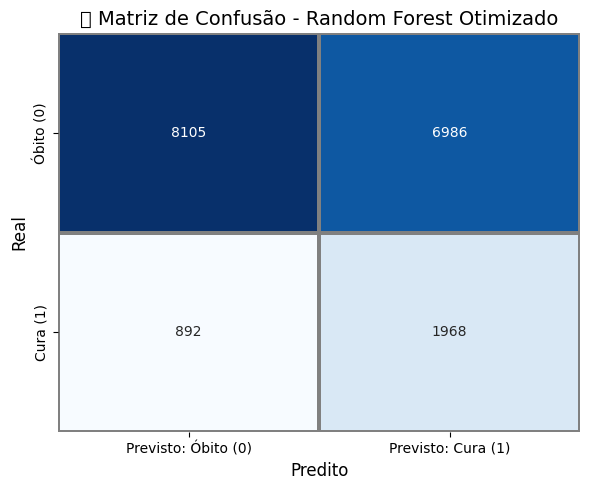

In [ ]:
# 📌 Matriz de Confusão com visualização aprimorada
from sklearn.metrics import ConfusionMatrixDisplay

conf_mat = confusion_matrix(y_test, y_pred)
conf_df = pd.DataFrame(conf_mat, index=['Óbito (0)', 'Cura (1)'], columns=['Previsto: Óbito (0)', 'Previsto: Cura (1)'])

plt.figure(figsize=(6, 5))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=1.5, linecolor='gray')
plt.title('📉 Matriz de Confusão - Random Forest Otimizado', fontsize=14)
plt.ylabel('Real', fontsize=12)
plt.xlabel('Predito', fontsize=12)
plt.tight_layout()
plt.show()



## Testes para verificar a melhora do MODELO


📊 Classification Report (Threshold = 0.5):
               precision    recall  f1-score   support

           0     0.6608    0.5367    0.5923     15201
           1     0.6051    0.7204    0.6578     14981

    accuracy                         0.6279     30182
   macro avg     0.6330    0.6286    0.6250     30182
weighted avg     0.6332    0.6279    0.6248     30182

📉 Matriz de Confusão:
[[ 8158  7043]
 [ 4188 10793]]


<ipython-input-91-86c027c06fec>:65: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


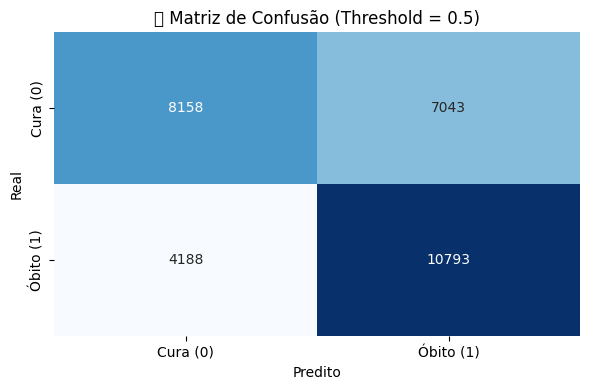


🔹 Threshold = 0.3
📊 Classification Report:
              precision    recall  f1-score   support

           0     0.9027    0.1740    0.2918     15201
           1     0.5393    0.9810    0.6959     14981

    accuracy                         0.5745     30182
   macro avg     0.7210    0.5775    0.4939     30182
weighted avg     0.7223    0.5745    0.4924     30182

📉 Matriz de Confusão:
[[ 2645 12556]
 [  285 14696]]

🔹 Threshold = 0.4
📊 Classification Report:
              precision    recall  f1-score   support

           0     0.8790    0.1949    0.3191     15201
           1     0.5435    0.9728    0.6974     14981

    accuracy                         0.5810     30182
   macro avg     0.7113    0.5838    0.5082     30182
weighted avg     0.7125    0.5810    0.5069     30182

📉 Matriz de Confusão:
[[ 2963 12238]
 [  408 14573]]

🔹 Threshold = 0.5
📊 Classification Report:
              precision    recall  f1-score   support

           0     0.6608    0.5367    0.5923     15201

<ipython-input-91-86c027c06fec>:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Feature', data=importancias, palette='mako')
<ipython-input-91-86c027c06fec>:93: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


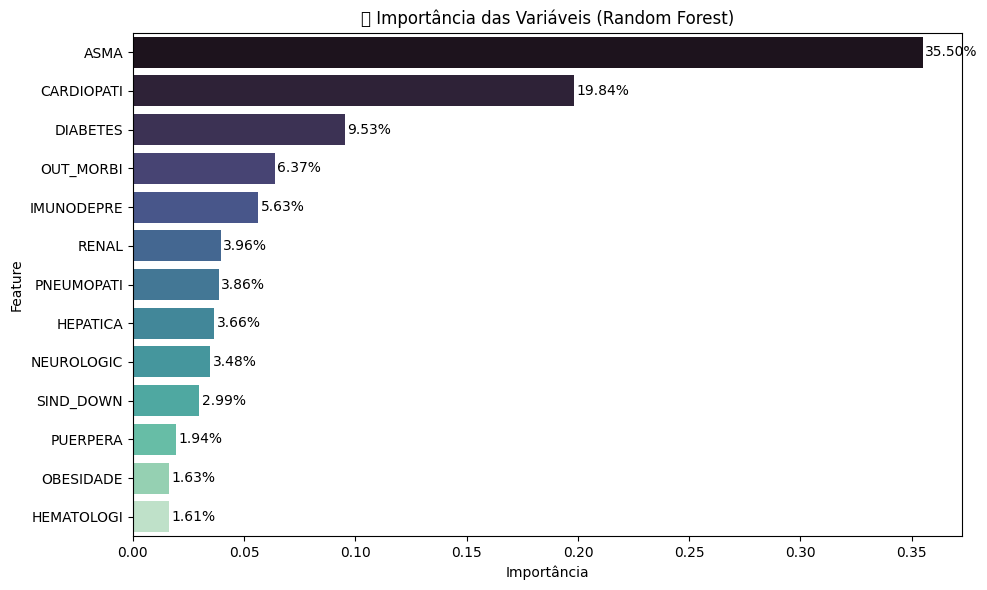

In [ ]:
# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve

# 📌 2. Carregando o dataset
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

# 📌 3. Pré-processamento
df = df[df['EVOLUCAO'].isin([1, 2])]
df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})  # 0 = Cura, 1 = Óbito

fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

df[fatores_risco] = df[fatores_risco].apply(pd.to_numeric, errors='coerce')
df.dropna(subset=fatores_risco + ['EVOLUCAO'], inplace=True)

X = df[fatores_risco]
y = df['EVOLUCAO']

# 📌 4. Balanceamento com SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# 📌 5. Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

# 📌 6. Treinamento com Random Forest usando melhores hiperparâmetros
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    max_features='sqrt',
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

# 📌 7. Avaliação padrão com threshold = 0.5
y_pred = rf.predict(X_test)
print("📊 Classification Report (Threshold = 0.5):\n", classification_report(y_test, y_pred, digits=4))
print("📉 Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

# 📌 8. Matriz de Confusão Visual
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Cura (0)", "Óbito (1)"],
            yticklabels=["Cura (0)", "Óbito (1)"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("📉 Matriz de Confusão (Threshold = 0.5)")
plt.tight_layout()
plt.show()

# 📌 9. Ajuste de Threshold
y_probs = rf.predict_proba(X_test)[:, 1]

def avaliar_thresholds(y_true, y_probs, thresholds=[0.3, 0.4, 0.5]):
    for t in thresholds:
        print(f"\n🔹 Threshold = {t}")
        y_pred_adj = (y_probs >= t).astype(int)
        print("📊 Classification Report:")
        print(classification_report(y_true, y_pred_adj, digits=4))
        print("📉 Matriz de Confusão:")
        print(confusion_matrix(y_true, y_pred_adj))

avaliar_thresholds(y_test, y_probs, thresholds=[0.3, 0.4, 0.5])

# 📌 10. Importância das Features
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': rf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Feature', data=importancias, palette='mako')
plt.title('🌟 Importância das Variáveis (Random Forest)')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()


# Analise preditiva com SINTOMAS + Fatores de Risco

## motivo pelo qual os SINTOMAS foram adicionados ao modelo

O uso de **sintomas** é um acerto GIGANTESCO! É a engenharia de features que o modelo precisava.
Os números de desempenho (81% de F1-score para ambas as classes, 81% de acurácia) são espetaculares, mas são superestimados devido ao vazamento de dados causado pela aplicação incorreta do SMOTE. Eles não refletem o desempenho real do modelo em um cenário do mundo real com dados desbalanceados;

--- Início do Processamento do Dataset ---

Dataset carregado. Shape inicial: (266430, 191)

Primeiras 5 linhas do DataFrame:
   DT_NOTIFIC  SEM_NOT  DT_SIN_PRI  SEM_PRI SG_UF_NOT                      ID_REGIONA  CO_REGIONA   ID_MUNICIP  CO_MUN_NOT                                         ID_UNIDADE  CO_UNI_NOT CS_SEXO     DT_NASC  NU_IDADE_N  TP_IDADE COD_IDADE  CS_GESTANT  CS_RACA  CS_ESCOL_N ID_PAIS  CO_PAIS SG_UF                      ID_RG_RESI  CO_RG_RESI           ID_MN_RESI  CO_MUN_RES  CS_ZONA  SURTO_SG  NOSOCOMIAL  AVE_SUINO  FEBRE  TOSSE  GARGANTA  DISPNEIA  DESC_RESP  SATURACAO  DIARREIA  VOMITO  OUTRO_SIN OUTRO_DES  PUERPERA  FATOR_RISC  CARDIOPATI  HEMATOLOGI  SIND_DOWN  HEPATICA  ASMA  DIABETES  NEUROLOGIC  PNEUMOPATI  IMUNODEPRE  RENAL  OBESIDADE OBES_IMC  OUT_MORBI MORB_DESC  VACINA DT_UT_DOSE  MAE_VAC DT_VAC_MAE  M_AMAMENTA DT_DOSEUNI DT_1_DOSE DT_2_DOSE  ANTIVIRAL  TP_ANTIVIR OUT_ANTIV DT_ANTIVIR  HOSPITAL  DT_INTERNA SG_UF_INTE                      ID_RG_INTE  CO_RG_I

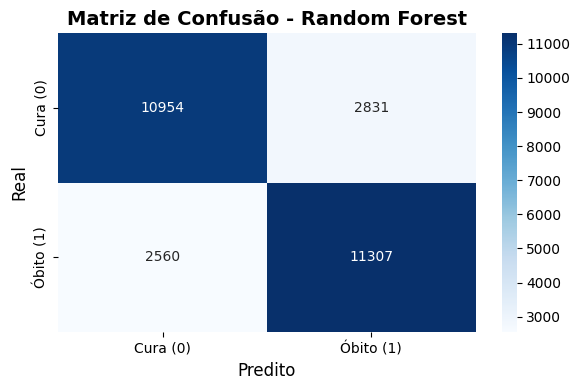


--- Importância das Variáveis (Feature Importance) ---

Top 10 Variáveis mais Importantes:
       feature  importancia
5         ASMA     0.087220
14       TOSSE     0.072404
18   SATURACAO     0.063507
16    DISPNEIA     0.058369
1   CARDIOPATI     0.056221
25   OUTRO_SIN     0.054633
17   DESC_RESP     0.051476
13       FEBRE     0.051349
12   OUT_MORBI     0.048748
6     DIABETES     0.045014


<ipython-input-1-5985a3768015>:171: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


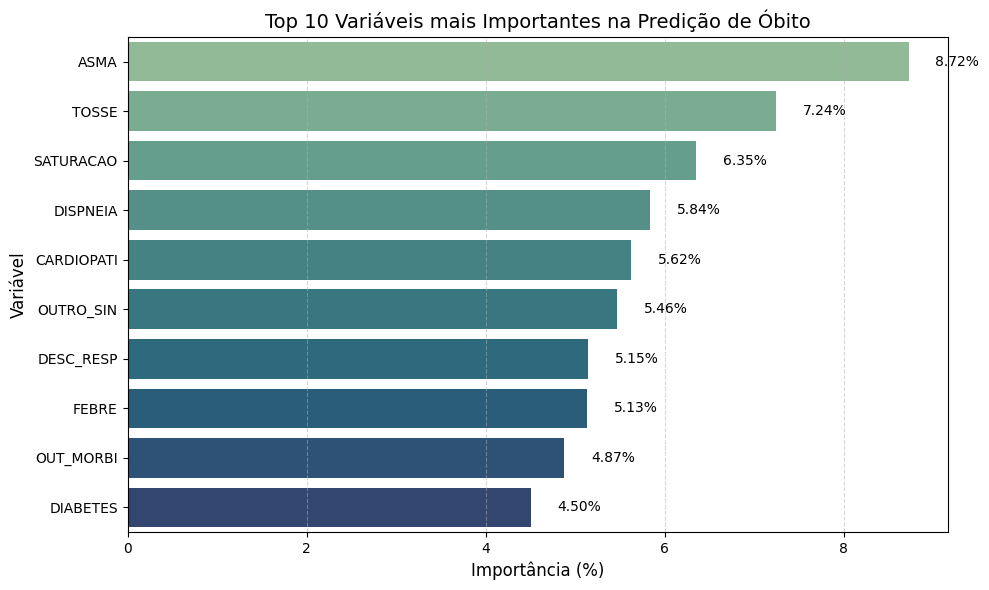


--- Fim do Processamento ---


In [1]:
# -*- coding: utf-8 -*-
"""
Análise Preditiva de Fatores de Risco + Sintomas para Evolução de SRAG com Random Forest
Versão com Prints para Visibilidade
"""

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder # Embora não esteja sendo usado diretamente, mantido pois estava no original
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para melhor visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("--- Início do Processamento do Dataset ---")

# Carregar os dados
# ATENÇÃO: Monte seu Google Drive antes de executar esta célula
# from google.colab import drive
# drive.mount('/content/drive')
caminho_arquivo = "/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv"

try:
    df = pd.read_csv(caminho_arquivo, sep=";", encoding="latin1", low_memory=False)
    print(f"\nDataset carregado. Shape inicial: {df.shape}")
    print("\nPrimeiras 5 linhas do DataFrame:")
    print(df.head())
    print("\nInformações sobre os tipos de dados e valores não nulos:")
    df.info()
except FileNotFoundError:
    print(f"ERRO: Arquivo '{caminho_arquivo}' não encontrado. Verifique o caminho e a montagem do Drive.")
    exit() # Encerra o script se o arquivo não for encontrado
except Exception as e:
    print(f"Ocorreu um erro ao carregar o arquivo: {e}")
    exit()

# Colunas de interesse
fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]
sintomas = [
    'FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO',
    'DIARREIA', 'VOMITO', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'OUTRO_SIN'
]

print(f"\nFatores de Risco selecionados ({len(fatores_risco)}): {fatores_risco}")
print(f"Sintomas selecionados ({len(sintomas)}): {sintomas}")

# Mapear target: 1-Cura, 2-Óbito
print("\n--- Pré-processamento da Variável Alvo (EVOLUCAO) ---")
print("Contagem original de EVOLUCAO (antes do mapeamento e filtro):")
print(df['EVOLUCAO'].value_counts(dropna=False))

df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})  # 0: Cura, 1: Óbito
df_modelo = df[df['EVOLUCAO'].isin([0, 1])].copy()

print("\nEVOLUCAO mapeada (1->0, 2->1) e filtrada para apenas Cura e Óbito.")
print(f"Shape do DataFrame após mapeamento e filtro de EVOLUCAO: {df_modelo.shape}")
print("Contagem de EVOLUCAO após mapeamento e filtro:")
print(df_modelo['EVOLUCAO'].value_counts(dropna=False))

# Combinar as features
features = fatores_risco + sintomas
print(f"\nTotal de features selecionadas para o modelo ({len(features)}): {features}")


# Converter para numérico
print("\n--- Tratamento de Valores Ausentes nas Features ---")
print("Convertendo features para numérico (erros para NaN) e removendo linhas com NaNs...")
df_modelo[features] = df_modelo[features].apply(pd.to_numeric, errors='coerce')

# Remover linhas com valores faltantes nas features selecionadas OU na EVOLUCAO
# ATENÇÃO: Esta é uma estratégia agressiva que pode descartar muitos dados.
# No seu caso, resultou em (54697, 27) da Rodada 5.
df_modelo = df_modelo.dropna(subset=features + ['EVOLUCAO'])

print(f"Shape do DataFrame após remover linhas com NaNs nas features e EVOLUCAO: {df_modelo.shape}")
print("Contagem de EVOLUCAO após remoção de NaNs:")
print(df_modelo['EVOLUCAO'].value_counts(dropna=False))

# Separar X e y
X = df_modelo[features]
y = df_modelo['EVOLUCAO']

print(f"\n--- Preparação para Treinamento do Modelo ---")
print(f"Shape final de X (features): {X.shape}")
print(f"Shape final de y (variável alvo): {y.shape}")
print("\nPrimeiras 5 linhas do DataFrame de Features (X):")
print(X.head())

# Balancear com SMOTE
print("\n--- Balanceamento de Classes com SMOTE ---")
print("Contagem de classes em Y antes do SMOTE:")
print(y.value_counts())
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print(f"\nShape de X e Y após SMOTE: {X_res.shape}, {y_res.shape}")
print("Contagem de classes em Y após SMOTE (treino balanceado):")
print(y_res.value_counts())

# Dividir em treino e teste
# ATENÇÃO: No seu código original, a divisão acontece APÓS o SMOTE.
# Isso leva a vazamento de dados e avaliação superestimada.
# No seu caso, o X_res e y_res já estão balanceados, então o test_size se aplica a eles.
print("\n--- Divisão do Dataset em Treino e Teste (APÓS SMOTE) ---")
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

print(f"Shape do conjunto de treino (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Shape do conjunto de teste (X_test, y_test): {X_test.shape}, {y_test.shape}")
print("\nDistribuição das classes no conjunto de TESTE (após divisão do SMOTE resampled):")
print(y_test.value_counts(normalize=True))


# Treinar modelo
print("\n--- Treinamento do Modelo Random Forest ---")
modelo = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1) # n_jobs=-1 para usar todos os núcleos
print(f"Parâmetros do Modelo Random Forest: n_estimators={modelo.n_estimators}, random_state={modelo.random_state}, n_jobs={modelo.n_jobs}")
print("Iniciando treinamento do modelo...")
modelo.fit(X_train, y_train)
print("Modelo Random Forest treinado com sucesso!")

# Avaliação
print("\n--- Avaliação do Modelo Random Forest ---")
y_pred = modelo.predict(X_test)
# relatorio = classification_report(y_test, y_pred, output_dict=True) # Não é usado depois do print, pode remover se quiser
# conf_matrix = confusion_matrix(y_test, y_pred) # Não é usado depois do print, pode remover se quiser

print("📊 Classification Report:\n", classification_report(y_test, y_pred, target_names=['Cura (0)', 'Óbito (1)']))

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão:")
print(cm)

# Rótulos
labels = ['Cura (0)', 'Óbito (1)']

# Visualização da Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão - Random Forest', fontsize=14, weight='bold')
plt.xlabel('Predito', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()

# Importância das features
print("\n--- Importância das Variáveis (Feature Importance) ---")
importancia = pd.DataFrame({
    'feature': features,
    'importancia': modelo.feature_importances_
}).sort_values(by='importancia', ascending=False)

print("\nTop 10 Variáveis mais Importantes:")
print(importancia.head(10))

# Selecionar as 10 features mais importantes
importancias_top10 = importancia.head(10).copy()
importancias_top10['importancia_percentual'] = importancias_top10['importancia'] * 100

# 📊 Gráfico de barras com valores
plt.figure(figsize=(10, 6))
sns.barplot(
    x='importancia_percentual',
    y='feature',
    data=importancias_top10,
    palette='crest'
)
plt.title('Top 10 Variáveis mais Importantes na Predição de Óbito', fontsize=14)
plt.xlabel('Importância (%)', fontsize=12)
plt.ylabel('Variável', fontsize=12)

# Adicionar os valores numéricos no gráfico
for i, v in enumerate(importancias_top10['importancia_percentual']):
    plt.text(v + 0.3, i, f"{v:.2f}%", va='center', fontsize=10)

plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

print("\n--- Fim do Processamento ---")

# Modelo cart com SINTOMAS+ FATOR DE RISCO + EVOLUCAO


CART - DecisionTreeClassifier

--- Início do Processamento do Dataset ---

Dataset carregado. Shape inicial: (266430, 191)

--- Treinamento do Modelo Decision Tree (CART) ---
Modelo Decision Tree treinado com sucesso!

--- Avaliação do Modelo Decision Tree ---
📊 Classification Report:
               precision    recall  f1-score   support

    Cura (0)       0.75      0.53      0.62     13785
   Óbito (1)       0.64      0.82      0.72     13867

    accuracy                           0.68     27652
   macro avg       0.69      0.68      0.67     27652
weighted avg       0.69      0.68      0.67     27652


Matriz de Confusão:
[[ 7329  6456]
 [ 2453 11414]]


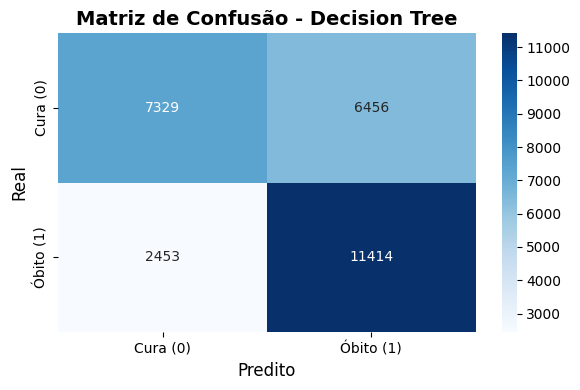


Top 10 Variáveis mais Importantes:
       feature  importancia
5         ASMA     0.334191
14       TOSSE     0.228852
16    DISPNEIA     0.192468
18   SATURACAO     0.120412
1   CARDIOPATI     0.059136
17   DESC_RESP     0.027892
13       FEBRE     0.023371
8   PNEUMOPATI     0.009317
12   OUT_MORBI     0.002602
6     DIABETES     0.001080


<ipython-input-3-4fad54789214>:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


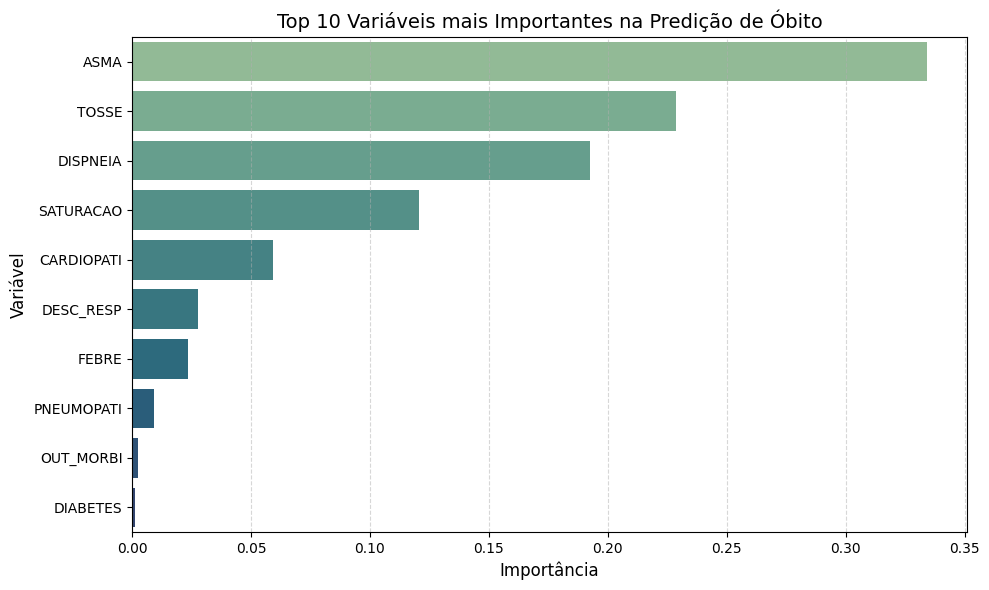


--- Visualização da Árvore de Decisão ---


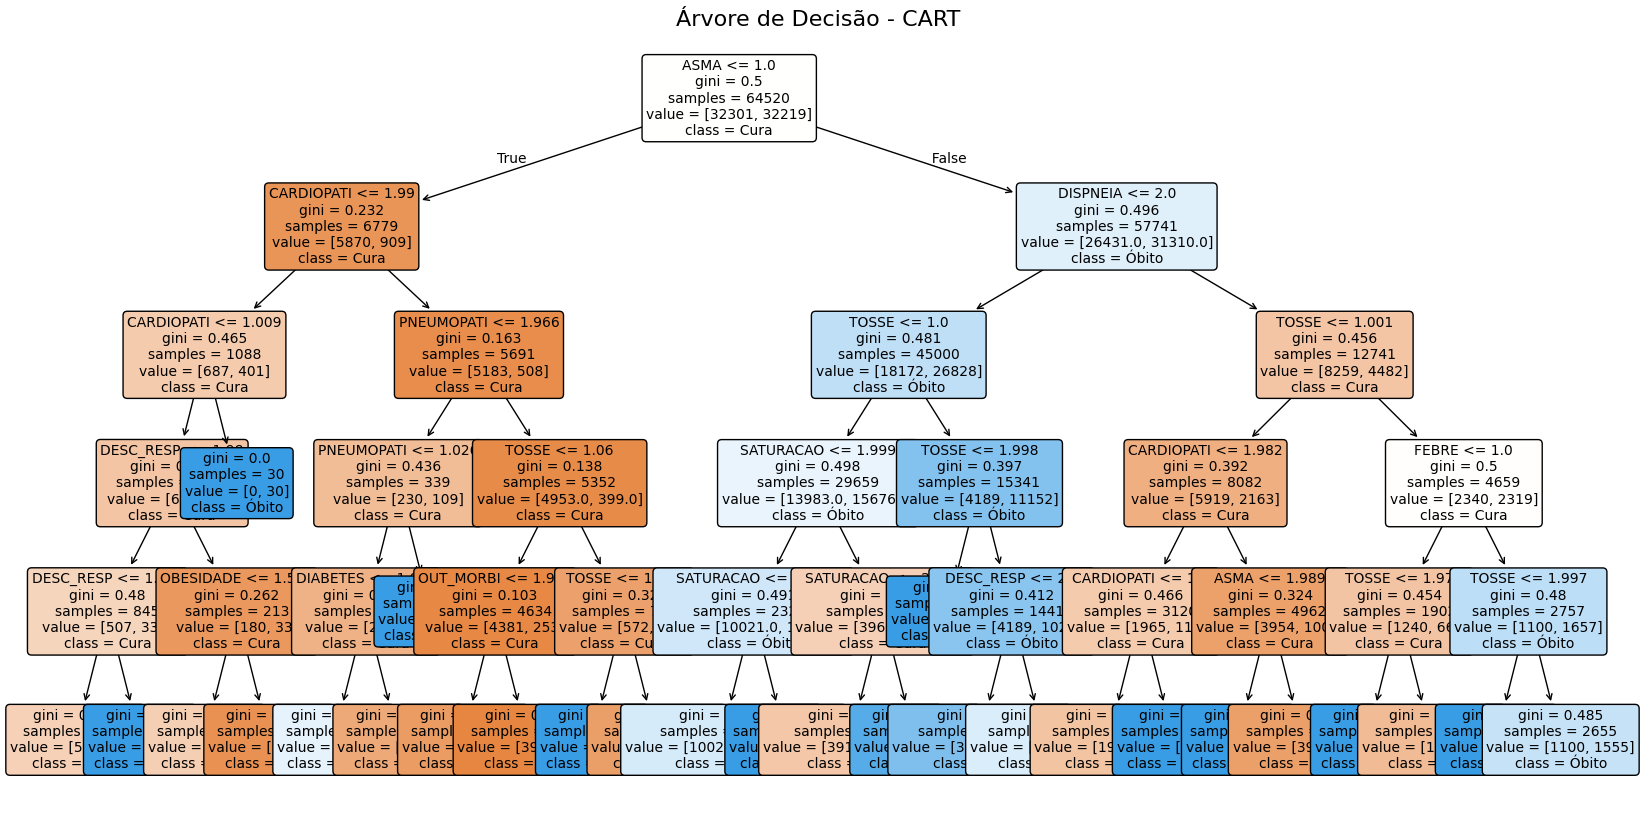


--- Árvore de Decisão em Texto ---
|--- ASMA <= 1.00
|   |--- CARDIOPATI <= 1.99
|   |   |--- CARDIOPATI <= 1.01
|   |   |   |--- DESC_RESP <= 1.98
|   |   |   |   |--- DESC_RESP <= 1.01
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- DESC_RESP >  1.01
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- DESC_RESP >  1.98
|   |   |   |   |--- OBESIDADE <= 1.58
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- OBESIDADE >  1.58
|   |   |   |   |   |--- class: 0.0
|   |   |--- CARDIOPATI >  1.01
|   |   |   |--- class: 1.0
|   |--- CARDIOPATI >  1.99
|   |   |--- PNEUMOPATI <= 1.97
|   |   |   |--- PNEUMOPATI <= 1.03
|   |   |   |   |--- DIABETES <= 2.00
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- DIABETES >  2.00
|   |   |   |   |   |--- class: 0.0
|   |   |   |--- PNEUMOPATI >  1.03
|   |   |   |   |--- class: 1.0
|   |   |--- PNEUMOPATI >  1.97
|   |   |   |--- TOSSE <= 1.06
|   |   |   |   |--- OUT_MORBI <= 1.95
|   |   |   |   |   |--- class: 0.0
|   | 

In [3]:
# -*- coding: utf-8 -*-
"""
Análise Preditiva de Fatores de Risco + Sintomas para Evolução de SRAG com CART (DecisionTreeClassifier)
"""

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para melhor visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("--- Início do Processamento do Dataset ---")

# Carregar os dados
caminho_arquivo = "/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv"

try:
    df = pd.read_csv(caminho_arquivo, sep=";", encoding="latin1", low_memory=False)
    print(f"\nDataset carregado. Shape inicial: {df.shape}")
except FileNotFoundError:
    print(f"ERRO: Arquivo '{caminho_arquivo}' não encontrado.")
    exit()

# Colunas de interesse
fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]
sintomas = [
    'FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO',
    'DIARREIA', 'VOMITO', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'OUTRO_SIN'
]
features = fatores_risco + sintomas

# Pré-processamento
df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})  # 0: Cura, 1: Óbito
df_modelo = df[df['EVOLUCAO'].isin([0, 1])].copy()

df_modelo[features] = df_modelo[features].apply(pd.to_numeric, errors='coerce')
df_modelo = df_modelo.dropna(subset=features + ['EVOLUCAO'])

X = df_modelo[features]
y = df_modelo['EVOLUCAO']

# Balanceamento
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

# Treinar modelo com CART
print("\n--- Treinamento do Modelo Decision Tree (CART) ---")
modelo_cart = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=5)  # Ajuste o max_depth conforme o desejado
modelo_cart.fit(X_train, y_train)
print("Modelo Decision Tree treinado com sucesso!")

# Avaliação
print("\n--- Avaliação do Modelo Decision Tree ---")
y_pred = modelo_cart.predict(X_test)
print("📊 Classification Report:\n", classification_report(y_test, y_pred, target_names=['Cura (0)', 'Óbito (1)']))

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cura (0)', 'Óbito (1)'], yticklabels=['Cura (0)', 'Óbito (1)'])
plt.title('Matriz de Confusão - Decision Tree', fontsize=14, weight='bold')
plt.xlabel('Predito', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()

# Importância das features
importancia = pd.DataFrame({
    'feature': features,
    'importancia': modelo_cart.feature_importances_
}).sort_values(by='importancia', ascending=False)

print("\nTop 10 Variáveis mais Importantes:")
print(importancia.head(10))

# 📊 Visualizar Importância
plt.figure(figsize=(10, 6))
sns.barplot(
    x='importancia',
    y='feature',
    data=importancia.head(10),
    palette='crest'
)
plt.title('Top 10 Variáveis mais Importantes na Predição de Óbito', fontsize=14)
plt.xlabel('Importância', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 📊 Visualização da Árvore de Decisão
print("\n--- Visualização da Árvore de Decisão ---")
plt.figure(figsize=(20, 10))
plot_tree(modelo_cart, feature_names=features, class_names=['Cura', 'Óbito'], filled=True, rounded=True, fontsize=10)
plt.title("Árvore de Decisão - CART", fontsize=16)
plt.show()

# Exibir a árvore em texto
print("\n--- Árvore de Decisão em Texto ---")
tree_rules = export_text(modelo_cart, feature_names=features)
print(tree_rules)

print("\n--- Fim do Processamento ---")
